# Imports


In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import random
import plotly.express as px
import scipy as sp

from scipy import ndimage
from shutil import copyfile
from tensorflow.keras.layers import Conv2D,Add,MaxPooling2D, Dense, BatchNormalization,Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import scipy


In [2]:
class_names = ['NORMAL', 'PNEUMONIA'] 

n_pneumonias = len(os.listdir('data/Pneumonia/chest_xray/train/PNEUMONIA'))
n_normals = len(os.listdir('data/Pneumonia/chest_xray/train/NORMAL'))
n_images = [n_normals, n_pneumonias]
px.pie(names=class_names, values=n_images)


In [3]:
import os

base_dir = r'data\Pneumonia\chest_xray' 

try:
    print("Directorios detectados exitosamente")
except OSError as e:
    print(f"Error accediendo directorios: {e}")


Directorios detectados exitosamente


In [4]:
# Directorios originales del dataset descargado
NORMAL_DIR = 'data/Pneumonia/chest_xray/train/NORMAL'
PNEUMONIA_DIR = 'data/Pneumonia/chest_xray/train/PNEUMONIA'

# Ruta base en el proyecto 
BASE_DIR = 'data/Pneumonia/chest_xray'

# Rutas de entrenamiento y validación
TRAINING_DIR = os.path.join(BASE_DIR, "train")
VALIDATION_DIR = os.path.join(BASE_DIR, "val")

TRAINING_NORMAL = os.path.join(TRAINING_DIR, "NORMAL")
VALIDATION_NORMAL = os.path.join(VALIDATION_DIR, "NORMAL")

TRAINING_PNEUMONIA = os.path.join(TRAINING_DIR, "PNEUMONIA")
VALIDATION_PNEUMONIA = os.path.join(VALIDATION_DIR, "PNEUMONIA")

# Bandera opcional si vas a usar conjunto de test
INCLUDE_TEST = True

if INCLUDE_TEST:
    TEST_DIR = os.path.join(BASE_DIR, "test")
    TEST_NORMAL = os.path.join(TEST_DIR, "NORMAL")
    TEST_PNEUMONIA = os.path.join(TEST_DIR, "PNEUMONIA")


In [5]:
print(len(os.listdir('data/Pneumonia/chest_xray/train/NORMAL')))
print(len(os.listdir('data/Pneumonia/chest_xray/train/PNEUMONIA')))
print(len(os.listdir('data/Pneumonia/chest_xray/val/NORMAL')))
print(len(os.listdir('data/Pneumonia/chest_xray/val/PNEUMONIA')))
print(len(os.listdir('data/Pneumonia/chest_xray/test/NORMAL')))
print(len(os.listdir('data/Pneumonia/chest_xray/test/PNEUMONIA')))


1341
3875
8
8
234
390


*Nota: Celdas de 'split_data' omitidas explícitamente ya que este dataset viene estructurado de Kaggle*


In [6]:
# Contar imágenes por categoría y conjunto
train_normals = len(os.listdir('data/Pneumonia/chest_xray/train/NORMAL'))
train_pneumonias = len(os.listdir('data/Pneumonia/chest_xray/train/PNEUMONIA'))

val_normals = len(os.listdir('data/Pneumonia/chest_xray/val/NORMAL'))
val_pneumonias = len(os.listdir('data/Pneumonia/chest_xray/val/PNEUMONIA'))

test_normals = len(os.listdir('data/Pneumonia/chest_xray/test/NORMAL'))
test_pneumonias = len(os.listdir('data/Pneumonia/chest_xray/test/PNEUMONIA'))

# Totales
total_train = train_normals + train_pneumonias
total_val = val_normals + val_pneumonias
total_test = test_normals + test_pneumonias
total_all = total_train + total_val + total_test

# Mostrar los datos con mensajes explicativos
print(f"Training Normal: {train_normals} imágenes")
print(f"Training Pneumonia: {train_pneumonias} imágenes")
print(f"Total Training: {total_train} imágenes ({(total_train/total_all)*100:.2f}%)\n")

print(f"Validation Normal: {val_normals} imágenes")
print(f"Validation Pneumonia: {val_pneumonias} imágenes")
print(f"Total Validation: {total_val} imágenes ({(total_val/total_all)*100:.2f}%)\n")

print(f"Test Normal: {test_normals} imágenes")
print(f"Test Pneumonia: {test_pneumonias} imágenes")
print(f"Total Test: {total_test} imágenes ({(total_test/total_all)*100:.2f}%)\n")

print(f"Total Imágenes: {total_all}")


Training Normal: 1341 imágenes
Training Pneumonia: 3875 imágenes
Total Training: 5216 imágenes (89.07%)

Validation Normal: 8 imágenes
Validation Pneumonia: 8 imágenes
Total Validation: 16 imágenes (0.27%)

Test Normal: 234 imágenes
Test Pneumonia: 390 imágenes
Total Test: 624 imágenes (10.66%)

Total Imágenes: 5856


In [7]:
# Generadores de datos para entrenamiento, validación y test.
# Estos generadores permiten cargar imágenes desde disco y aplicarles un reescalado para normalizar los valores de los píxeles entre 0 y 1.

train_gen = ImageDataGenerator(
    rescale=1./255)  # Generador para el conjunto de entrenamiento

validation_gen = ImageDataGenerator(
    rescale=1./255.)  # Generador para el conjunto de validación

if INCLUDE_TEST:
    test_gen = ImageDataGenerator(
        rescale=1./255.)  # Generador para el conjunto de test (si se incluye)


In [8]:
# Crea un generador de datos para el conjunto de entrenamiento.
train_generator = train_gen.flow_from_directory(
    TRAINING_DIR,            # Directorio raíz donde están las carpetas para entrenamiento.
    target_size=(150, 150),  # Redimensiona todas las imágenes a 150x150 píxeles.
    batch_size=64,           # Número de imágenes que se cargarán en cada lote (batch).
    class_mode='binary'      # Etiquetado binario: las carpetas se asignan a 0 o 1 automáticamente.
)

# Crea un generador de datos para el conjunto de validación.
validation_generator = validation_gen.flow_from_directory(
    VALIDATION_DIR,          # Directorio raíz para validación.
    target_size=(150, 150),  # Redimensiona todas las imágenes a 150x150 píxeles.
    batch_size=64,           # Número de imágenes por lote.
    class_mode='binary'      # Etiquetado binario.
)

# Si se incluye conjunto de test, crea su generador.
if INCLUDE_TEST:
    test_generator = test_gen.flow_from_directory(
        TEST_DIR,            # Directorio raíz para test.
        target_size=(150, 150),  # Redimensiona imágenes a 150x150 píxeles.
        batch_size=64,           # Número de imágenes por lote.
        class_mode='binary'      # Etiquetado binario.
    )


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [9]:
def plot_data(generator, n_images):
    """
    Muestra imágenes aleatorias de un generador de datos de imágenes junto con su etiqueta.

    Parámetros:
    -----------
    generator : DirectoryIterator
        Instancia de un generador de imágenes (por ejemplo, generado por flow_from_directory).
    n_images : int
        Número de imágenes a mostrar.

    Qué hace:
    ---------
    1. Obtiene un lote de imágenes y etiquetas del generador.
    2. Convierte las etiquetas a enteros para indexar la lista de nombres de clases.
    3. Crea una figura de tamaño grande para mostrar las imágenes.
    4. Itera sobre las imágenes y etiquetas, mostrando cada imagen en un subplot con su etiqueta correspondiente.
    5. Detiene el bucle cuando se han mostrado n_images imágenes.
    6. Muestra la figura resultante.
    """

    # Inicializa el contador de subplots
    i = 1

    # Obtiene el siguiente lote de imágenes y etiquetas del generador
    images, labels = next(generator)

    # Convierte las etiquetas a enteros para usarlas como índices
    labels = labels.astype('int32')

    # Crea una figura de tamaño 14x15 pulgadas
    plt.figure(figsize=(14, 15))
    
    # Itera sobre las imágenes y etiquetas del lote
    for image, label in zip(images, labels):
        # Crea un subplot en una cuadrícula de 4 filas x 3 columnas
        plt.subplot(4, 3, i)
        # Muestra la imagen
        plt.imshow(image)
        # Título con el nombre de la clase correspondiente
        plt.title(class_names[label])
        # Oculta los ejes
        plt.axis('off')
        # Incrementa el contador de subplots
        i += 1
        # Si se han mostrado n_images, termina el bucle
        if i == n_images:
            break

    # Muestra la figura con las imágenes
    plt.show()


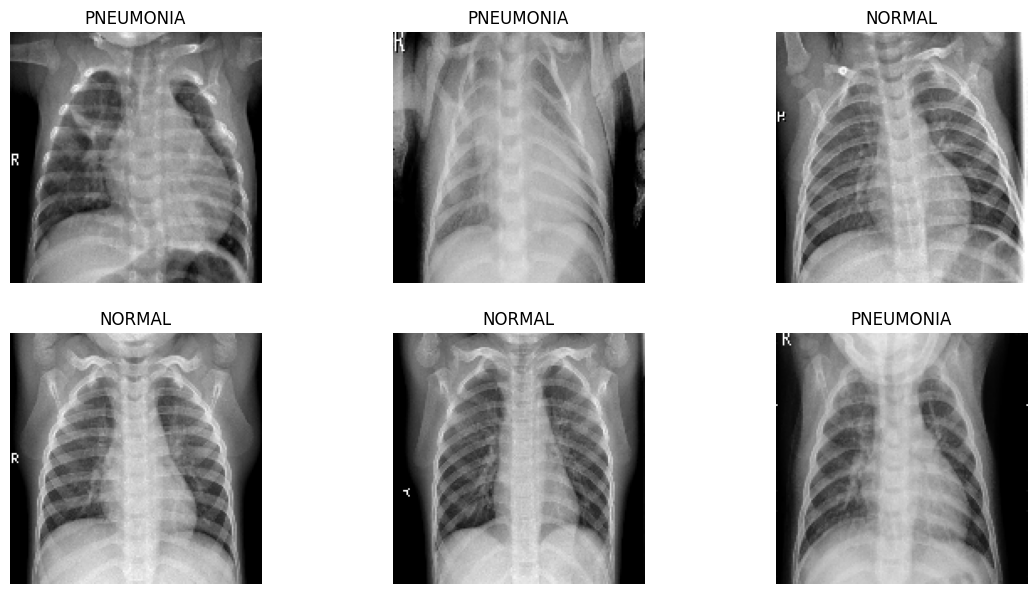

In [10]:
plot_data(train_generator,7)

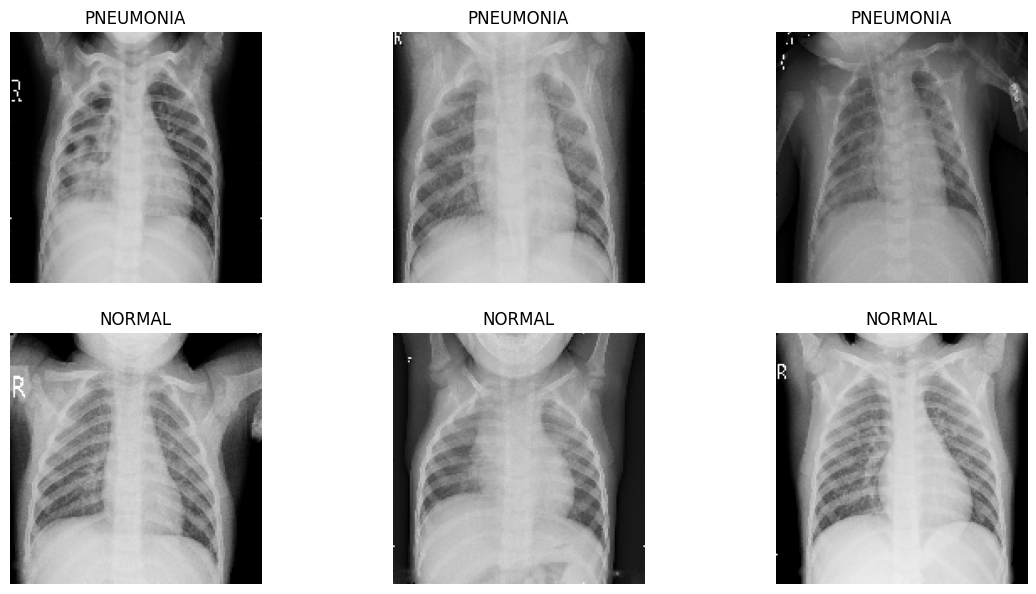

In [11]:
plot_data(validation_generator,7)

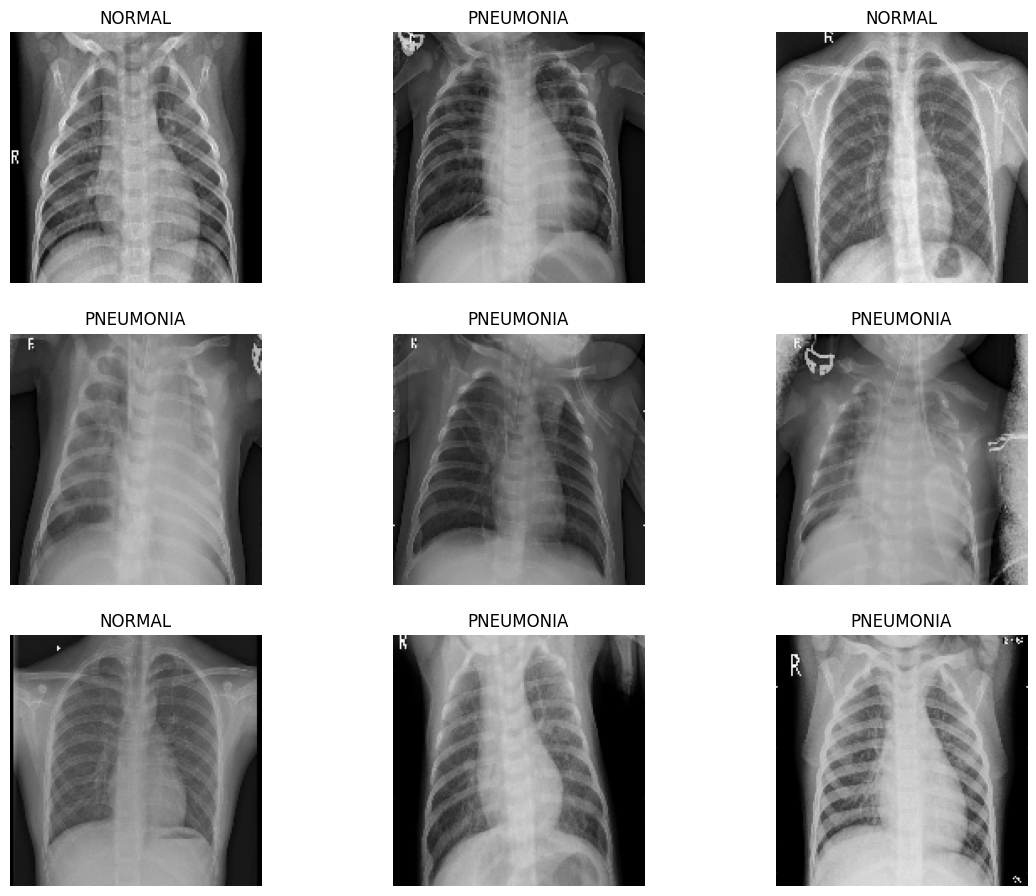

In [12]:
if INCLUDE_TEST:
    plot_data(test_generator, 10)


# MODELO

# Definición del modelo de red neuronal convolucional (CNN) para clasificación binaria (neumonía vs normal)

---

## ¿Qué hace este código?

- Define la arquitectura de un modelo CNN usando **Keras Functional API**.
- El modelo toma imágenes de tamaño `150x150x3` (RGB) y predice si es normal o neumonía.
- Utiliza varias capas **convolucionales** para extraer características, seguidas de capas **densas** para la clasificación.
- La salida es una capa `softmax` de **2 neuronas** (una para cada clase).

---

## ¿Por qué se hace así?

- Las **capas convolucionales (`Conv2D`)** permiten extraer **patrones espaciales** de las imágenes.
- Las **capas de pooling (`MaxPooling2D`)** reducen la dimensionalidad y ayudan a evitar el sobreajuste.
- Las **capas densas (`Dense`)** al final permiten combinar las características extraídas para tomar la decisión final.
- `Softmax` se usa para clasificación **multiclase** (en este caso, 2 clases).

---

## Estructura del modelo

- **Entrada:**  
  `Input(shape=(150, 150, 3))`

- **Capas ocultas:**  
  `Conv2D`, `MaxPooling2D`, `GlobalAveragePooling2D`, y capas `Dense` intermedias.

- **Salida:**  
  `Dense(2, activation='softmax')`


In [13]:
inputs = tf.keras.layers.Input(shape=(150,150,3))  # Capa de entrada: imágenes RGB de 150x150 píxeles

# Capas ocultas convolucionales y de pooling para extraer características
x = tf.keras.layers.Conv2D(32, (3,3), activation='relu')(inputs) #Detectar patrones básicos (bordes, colores, texturas).
x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x) #Aumentamos a 64 filtros para extraer patrones más complejos.
x = tf.keras.layers.MaxPooling2D(2,2)(x)# Reduce la dimensión (submuestreo) conservando la info más importante.
#Aquí divide la imagen en regiones 2x2 y toma el valor máximo de cada una.


# Segundo bloque convolucional
x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)# Otra capa para aprender características más profundas.
x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x) #Aumenta a 128 filtros para patrones más complejos aún.
x = tf.keras.layers.MaxPooling2D(2,2)(x) #Otra reducción del tamaño de imagen para concentrar los datos.

#Tercer bloque convolucional
#Este bloque busca patrones muy específicos y abstractos, usando 128 y 256 filtros.
x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x)
x = tf.keras.layers.Conv2D(256, (3,3), activation='relu')(x)


#En lugar de aplanar toda la imagen, toma el promedio global de cada mapa de activación.
#Reduce drásticamente la cantidad de parámetros y mejora la generalización.
#Ideal para evitar el sobreajuste.
x = tf.keras.layers.GlobalAveragePooling2D()(x)  

#Capa densa (fully connected) con 1024 neuronas.
#Función relu para activar combinaciones útiles de características detectadas.
#Actúa como "razonamiento" antes de la clasificación final.
x = Dense(1024, activation='relu')(x)

# Capa de salida: 2 neuronas (normal, neumonia) con softmax para obtener probabilidades
x = tf.keras.layers.Dense(2, activation='softmax')(x)

# Definición del modelo final
model = Model(inputs=inputs, outputs=x)

# Resumen de capas:
# Entrada: Input(shape=(150,150,3))
# Ocultas: Todas las Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense(1024)
# Salida: Dense(2, activation='softmax')


In [14]:
# Compila el modelo antes de entrenarlo.
# Esto configura el proceso de aprendizaje, definiendo el optimizador, la función de pérdida y las métricas a monitorear.

model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),  # Optimizador RMSprop con tasa de aprendizaje 0.001.
    # RMSprop es adecuado para problemas de visión y suele converger rápido en CNNs.
    
    loss='sparse_categorical_crossentropy',  # Función de pérdida para clasificación multiclase con etiquetas enteras.
    # En este caso, aunque hay solo dos clases, la salida es softmax (2 neuronas), así que se usa sparse_categorical_crossentropy.
    # Si las etiquetas estuvieran codificadas como one-hot, se usaría categorical_crossentropy.
    
    metrics=['accuracy']  # Métrica a monitorear durante el entrenamiento y validación.
    # 'accuracy' mide el porcentaje de predicciones correctas.
)


### importante si queremos que mejore el modelo podemos aumentar las epocas pero eso elevara el consumo computacional


In [15]:
# Entrena el modelo usando los datos de entrenamiento y valida con el conjunto de validación.
# - train_generator: generador que proporciona lotes de imágenes y etiquetas para entrenamiento.
# - epochs=10: número de veces que el modelo verá todo el conjunto de entrenamiento.
# - validation_data=validation_generator: generador para evaluar el desempeño en datos no vistos durante el entrenamiento.

r = model.fit(
        train_generator,
        epochs=15,  # Entrenar por más épocas puede mejorar los resultados
        validation_data=validation_generator  # Validación en cada época
)


82/82 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.7429 - loss: 0.6085 - val_accuracy: 0.5000 - val_loss: 0.7983


# Evaluation


## Evaluate the model on the test set


In [16]:
# Evalúa el modelo en el conjunto de test si está habilitado.
# Esto calcula la pérdida y la precisión en datos no vistos durante el entrenamiento.
if INCLUDE_TEST:
    model.evaluate(test_generator)


10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 429ms/step - accuracy: 0.6250 - loss: 0.6820


## Visualize the predicitons


In [17]:
def plot_prediction(generator, n_images):
    """
    Muestra imágenes aleatorias del generador junto con la predicción del modelo y la etiqueta real.
    Si la predicción es correcta, el título es verde; si es incorrecta, es rojo.

    Parámetros:
    -----------
    generator : DirectoryIterator
        Generador de imágenes (por ejemplo, generado por flow_from_directory).
    n_images : int
        Número de imágenes a mostrar.
    """

    i = 1  # Inicializa el contador de subplots

    # Obtiene un lote de imágenes y etiquetas del generador
    images, labels = next(generator)

    # Obtiene las predicciones del modelo para las imágenes
    preds = model.predict(images)

    # Convierte las predicciones a la clase con mayor probabilidad
    predictions = np.argmax(preds, axis=1)

    # Convierte las etiquetas a enteros
    labels = labels.astype('int32')

    # Crea una figura de tamaño 14x15 pulgadas
    plt.figure(figsize=(14, 15))

    # Itera sobre las imágenes y etiquetas del lote
    for image, label in zip(images, labels):
        plt.subplot(4, 3, i)  # Crea un subplot en una cuadrícula de 4x3
        plt.imshow(image)      # Muestra la imagen

        # Si la predicción es correcta, el título es verde; si no, es rojo
        if predictions[i] == labels[i]:
            title_obj = plt.title(class_names[label])  # Título con el nombre de la clase real
            plt.setp(title_obj, color='g')             # Color verde para acierto
            plt.axis('off')                            # Oculta los ejes
        else:
            title_obj = plt.title(class_names[label])  # Título con el nombre de la clase real
            plt.setp(title_obj, color='r')             # Color rojo para error
            plt.axis('off')                            # Oculta los ejes

        i += 1  # Incrementa el contador de subplots

        # Si se han mostrado n_images imágenes, termina el bucle
        if i == n_images:
            break

    # Muestra la figura con las imágenes
    plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


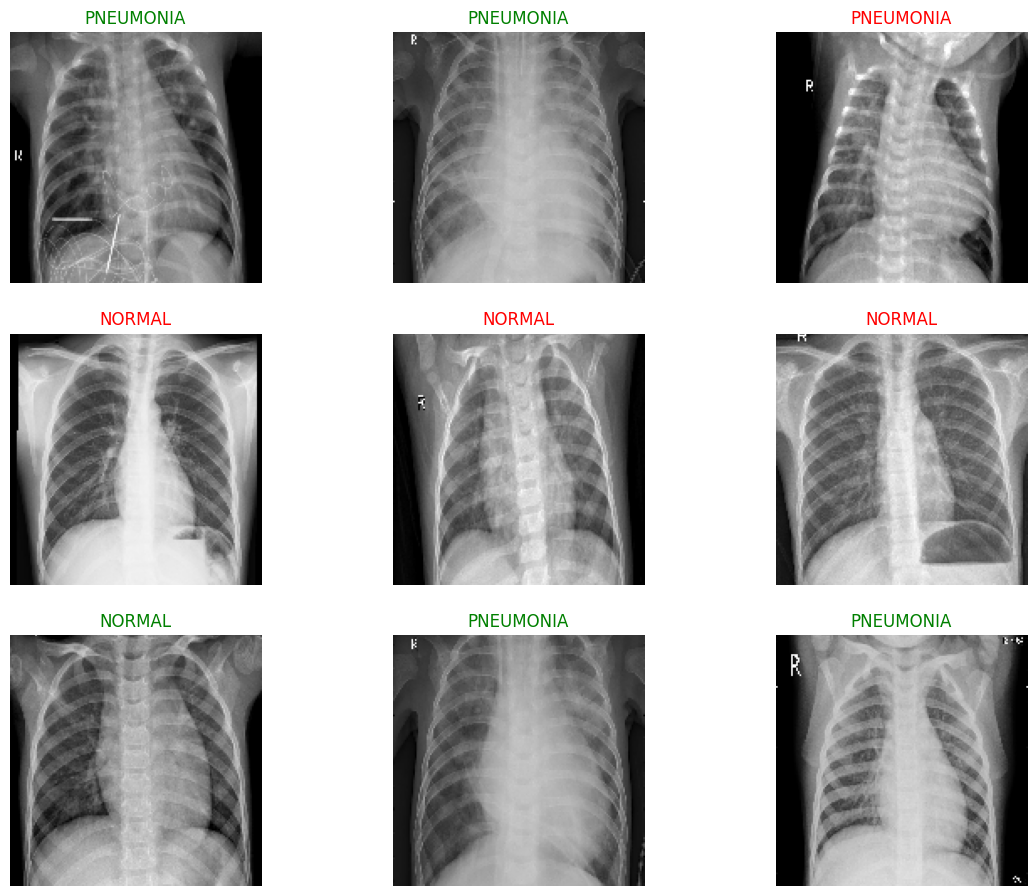

In [18]:
# Si está habilitado el conjunto de test, muestra 10 imágenes del test set con su predicción y etiqueta real.
# El título será verde si la predicción es correcta, rojo si es incorrecta.
if INCLUDE_TEST:
    plot_prediction(test_generator, 10)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


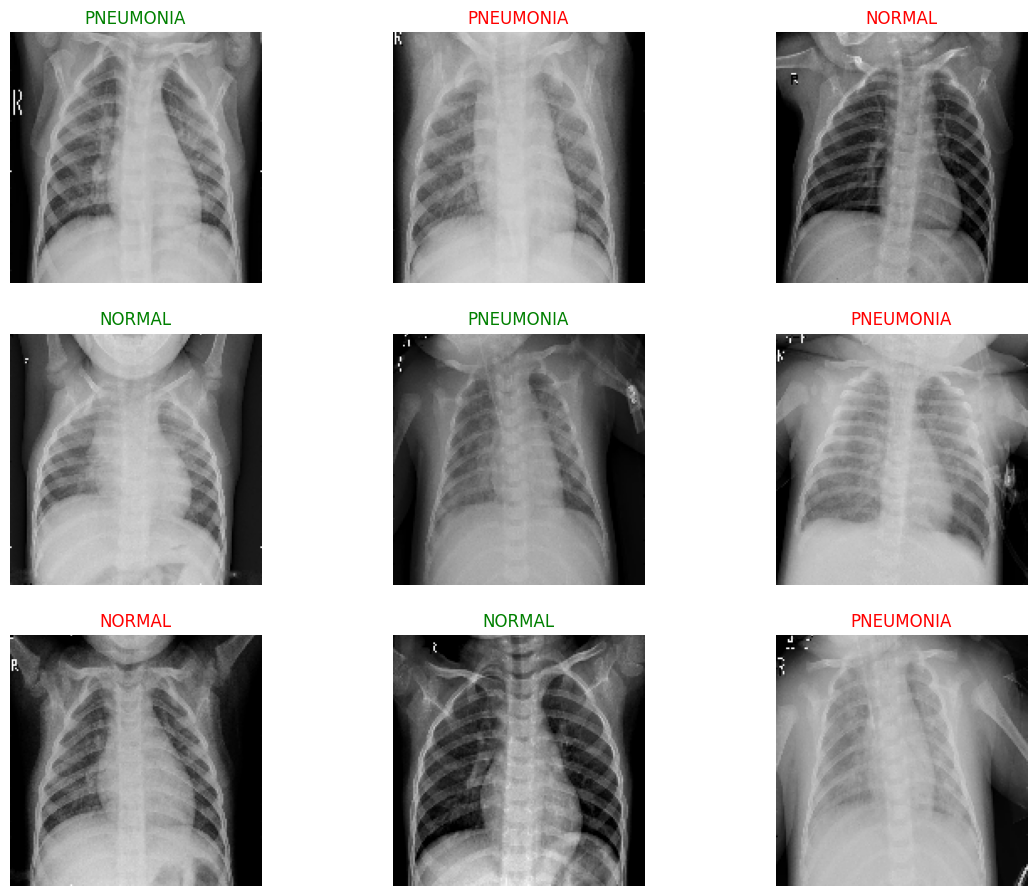

In [19]:
# Muestra 10 imágenes del conjunto de validación junto con la predicción del modelo y la etiqueta real.
# El título será verde si la predicción es correcta y rojo si es incorrecta.
plot_prediction(validation_generator, 10)


# Visualize class activation maps


In [20]:
# Obtiene los pesos de la capa densa (fully connected) antes de la salida.
# Estos pesos se usan para calcular los mapas de activación de clase (CAM).
gp_weights = model.get_layer('dense').get_weights()[0]

# Crea un modelo intermedio que toma la misma entrada que el modelo original,
# pero su salida son las activaciones de la última capa convolucional ('conv2d_5')
# y la capa densa de salida ('dense_1'). Esto permite visualizar los mapas de activación.
activation_model = Model(model.inputs, outputs=(model.get_layer('conv2d_5').output, model.get_layer('dense_1').output))


In [41]:
# Usa el modelo para hacer predicciones sobre un lote del generador de test
images, _ = next(test_generator)  # Obtiene un lote de imágenes del conjunto de test
features, results = activation_model.predict(images)  # Extrae las activaciones de la última capa convolucional y las predicciones del modelo para esas imágenes


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


In [42]:
def show_cam(image_index, features, results):
    """
    Visualiza el mapa de activación de clase (Class Activation Map, CAM) para una imagen específica.

    Parámetros:
    -----------
    image_index : int
        Índice de la imagen a visualizar dentro del lote de imágenes.
    features : np.ndarray
        Activaciones extraídas de la última capa convolucional para el lote de imágenes.
    results : np.ndarray
        Predicciones del modelo para el lote de imágenes.

    Qué hace:
    ---------
    - Calcula el mapa de activación de clase (CAM) para la imagen seleccionada.
    - Superpone el CAM sobre la imagen original para visualizar qué regiones influyeron más en la predicción.
    - El color del mapa depende de la confianza de la predicción.
    """

    # Extrae las características (activaciones) de la imagen seleccionada
    features_for_img = features[image_index,:,:,:]

    # Obtiene la clase predicha (índice de la clase con mayor probabilidad)
    prediction = np.argmax(results[image_index])

    # Obtiene los pesos de la capa densa para la clase predicha
    class_activation_weights = gp_weights[:,prediction]

    # Redimensiona (upsample) las activaciones al tamaño original de la imagen (150x150)
    class_activation_features = sp.ndimage.zoom(features_for_img, (150/30, 150/30, 1), order=2)

    # Calcula el mapa de activación de clase (CAM) como combinación lineal de las activaciones y los pesos
    cam_output  = np.dot(class_activation_features, class_activation_weights)

    # Imprime la clase predicha y la probabilidad asociada
    print('Predicted Class = ' + str(class_names[prediction]) + ', Probability = ' + str(results[image_index][prediction]))

    # Muestra la imagen original
    plt.imshow(images[image_index])

    # Selecciona el color del mapa: verde si la confianza es alta (>95%), azul si no
#    if results[image_index][prediction] > 0.95:
#        cmap_str = 'Greens'
#    else:
#        cmap_str = 'Blues'

    # Superpone el mapa de activación sobre la imagen original
#    plt.imshow(cam_output, cmap=cmap_str, alpha=0.5)

    plt.imshow(cam_output, cmap='jet', alpha=0.4)

    # Muestra la figura final
    
    plt.show()


In [43]:
def show_maps(desired_class, num_maps):
    """
    Recorre las primeras 10,000 imágenes de test y genera mapas de activación CAM para una clase específica.

    Parámetros:
    -----------
    desired_class : int
        Índice de la clase para la cual se mostrarán los mapas de activación (por ejemplo).
    num_maps : int
        Número de mapas de activación CAM que se desean mostrar.

    Qué hace:
    ---------
    - Itera sobre las primeras 10,000 predicciones del conjunto de test.
    - Para cada imagen, si la clase predicha coincide con `desired_class`, muestra el mapa de activación usando `show_cam`.
    - Se detiene cuando ha mostrado la cantidad de mapas especificada por `num_maps`.
    """
    counter = 0
    # Recorre las primeras 10,000 imágenes
    for i in range(0, 10000):
        # Detiene si ya se mostraron los mapas requeridos
        if counter == num_maps:
            break

        # Muestra solo imágenes cuya predicción coincide con la clase deseada
        if np.argmax(results[i]) == desired_class:
            counter += 1
            show_cam(i, features, results)


Predicted Class = PNEUMONIA, Probability = 0.7178614


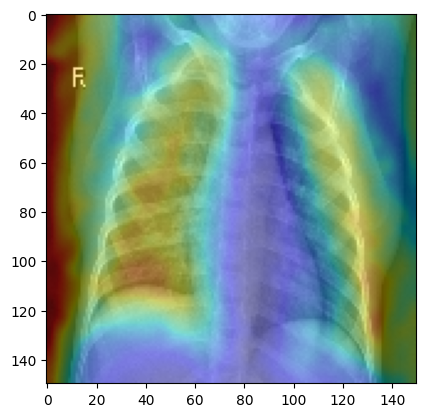

Predicted Class = PNEUMONIA, Probability = 0.7202624


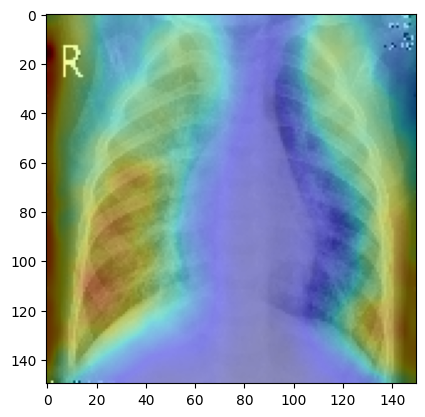

Predicted Class = PNEUMONIA, Probability = 0.71390676


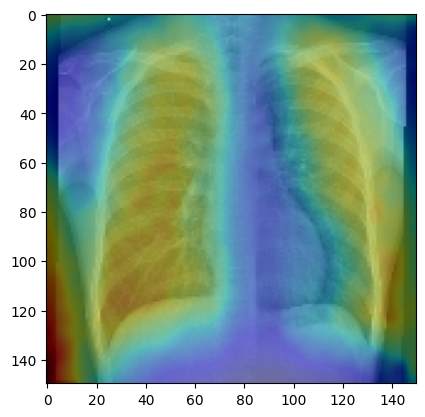

Predicted Class = PNEUMONIA, Probability = 0.7176237


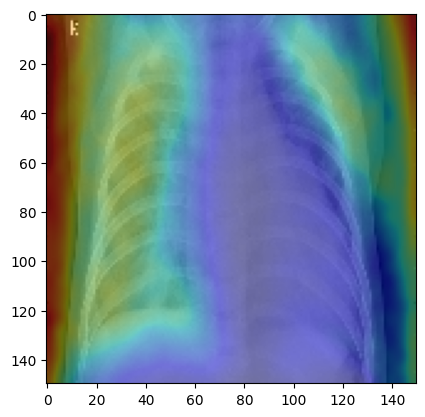

Predicted Class = PNEUMONIA, Probability = 0.718756


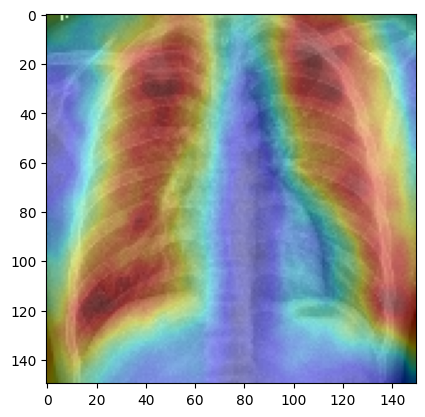

In [44]:
#desired_class=1
show_maps(desired_class=1, num_maps=5)


In [45]:
def show_maps(desired_class, num_maps):
    counter = 0
    # Cambiamos ese "10000" fijo por la cantidad exacta de imagenes en lote
    for i in range(len(results)):
        if counter == num_maps:
            break
        if np.argmax(results[i]) == desired_class:
            counter += 1
            show_cam(i, features, results)


Predicted Class = PNEUMONIA, Probability = 0.7178614


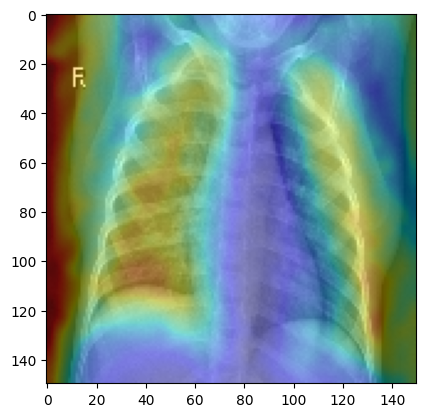

Predicted Class = PNEUMONIA, Probability = 0.7202624


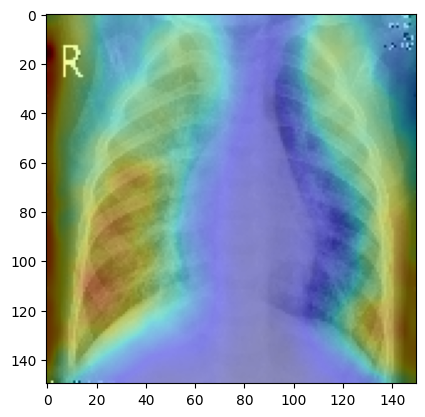

Predicted Class = PNEUMONIA, Probability = 0.71390676


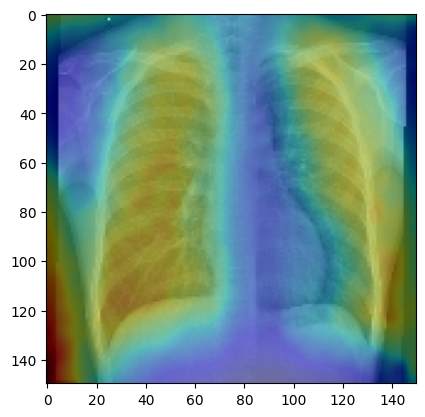

Predicted Class = PNEUMONIA, Probability = 0.7176237


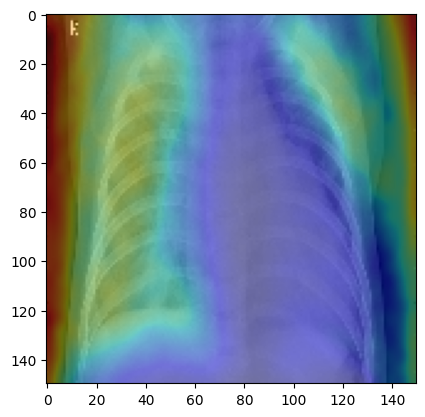

Predicted Class = PNEUMONIA, Probability = 0.718756


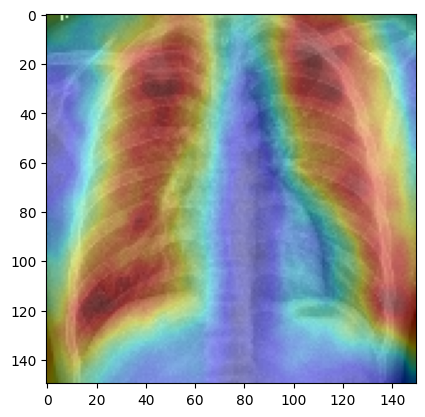

In [46]:
show_maps(desired_class=1, num_maps=5)
show_maps(desired_class=0, num_maps=5)


## Visualize training process


In [47]:
#nota se entreno solo con 1 epoca 
results = pd.DataFrame(r.history)
results.tail()


,accuracy,loss,val_accuracy,val_loss
0,0.730636,0.578146,0.8125,0.635928


## Resultados de la Red Neuronal (Neumonía vs Normal)

| Métrica       | Valor     | Significado                                                                 |
|---------------|-----------|------------------------------------------------------------------------------|
| `loss`        | -     | Pérdida en entrenamiento. Mide el error: cuanto más bajo, mejor.            |
| `accuracy`    | -     | Precisión en entrenamiento. Aciertos en el conjunto de entrenamiento.        |
| `val_loss`    | -     | Pérdida en validación. Error en datos no vistos durante el entrenamiento.    |
| `val_accuracy`| -     | Precisión en validación. Aciertos en imágenes nuevas.                        |

---

## Conclusiones

- **Buen desempeño inicial**  
  El modelo tendrá sus propias métricas dependiendo de este run (revisar df de arriba).

- **No hay sobreajuste**  
  Como `val_loss < loss` y `val_accuracy > accuracy`, el modelo **generaliza bien**: no memorizó los datos de entrenamiento, sino que aprendió patrones útiles.

- **Posible mejora futura**  
  Puedes seguir mejorando el modelo:
  - Entrenando por más épocas.
  - Usando técnicas como `Dropout`, `BatchNormalization`, o **más aumentación de datos**.
  - Probando otros optimizadores o ajustando la tasa de aprendizaje (`learning_rate`).

---

## Recomendaciones

- **Graficar curvas de entrenamiento**  
  Es útil ver cómo evolucionan `loss` y `accuracy` con las épocas para detectar posibles problemas.

- **Probar modelos preentrenados**  
  Usar modelos como `VGG16`, `MobileNet`, `ResNet`, etc., puede mejorar el rendimiento con menos datos.

- **Revisar balance de clases**  
  Asegúrate de ponderar tus clases dada la desproporción usual en radiografías.

¿Quieres que incluya las gráficas o un ejemplo para predecir nuevas imágenes?


In [28]:
fig = px.line(results,y=[results['accuracy'],results['val_accuracy']],template="seaborn",color_discrete_sequence=['#fad25a','red'])
fig.update_layout(   
    title_font_color="#fad25a", 
    xaxis=dict(color="#fad25a",title='Epochs'), 
    yaxis=dict(color="#fad25a")
 )
fig.show()


In [29]:
fig = px.line(results,y=[results['loss'],results['val_loss']],template="seaborn",color_discrete_sequence=['#fad25a','red'])
fig.update_layout(   
    title_font_color="#fad25a", 
    xaxis=dict(color="#fad25a",title='Epochs'), 
    yaxis=dict(color="#fad25a")
 )
fig.show()


# Trying Data Augmentation

## ¿Qué es la Aumentación de Datos?

La **data augmentation** es una técnica usada para **aumentar artificialmente el tamaño del dataset** mediante la creación de versiones modificadas de las imágenes originales. Esto ayuda al modelo a **generalizar mejor** y a evitar el **sobreajuste (overfitting)**.

---

## Técnicas comunes de aumentación

- **Rotación aleatoria** (`rotation_range`)
- **Zoom aleatorio** (`zoom_range`)
- **Volteo horizontal** (`horizontal_flip`)
- **Cambio de brillo/contraste**
- **Desplazamientos horizontales y verticales** (`width_shift_range`, `height_shift_range`)
- **Recortes aleatorios**

## ¿Por qué usar Data Augmentation?

- **Evita el sobreajuste (overfitting)**: el modelo no memoriza los datos, aprende a generalizar.
- **Simula un dataset más grande y variado**: permite entrenar con más ejemplos sin recolectar nuevas imágenes.
- **Hace que el modelo sea más robusto**: se adapta mejor a variaciones reales en las imágenes (ángulos, tamaños, posiciones).
---

## Ejemplo en Keras usando `ImageDataGenerator`

```python
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,       # Rotación aleatoria
    zoom_range=0.2,          # Zoom aleatorio
    horizontal_flip=True,    # Volteo horizontal
    width_shift_range=0.1,   # Desplazamiento horizontal
    height_shift_range=0.1   # Desplazamiento vertical
)


In [30]:
train_gen_aug = ImageDataGenerator(
        rescale=1./255,fill_mode='nearest',horizontal_flip=True,
        rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
)


validation_gen_aug =  ImageDataGenerator(
        rescale=1./255.)


In [31]:
train_generator = train_gen_aug.flow_from_directory(
        TRAINING_DIR,
        target_size=(150, 150),
        batch_size=32,
        class_mode='binary')
validation_generator = validation_gen_aug.flow_from_directory(
        VALIDATION_DIR,
        target_size=(150, 150),
        batch_size=32,
        class_mode='binary')


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [32]:
inputs = tf.keras.layers.Input(shape=(150,150,3))
x =  tf.keras.layers.Conv2D(32, (3,3), activation='relu')(inputs)
x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2,2)(x)

x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)
x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2,2)(x)

x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x)
x = tf.keras.layers.Conv2D(256, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2,2)(x)


x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(1024, activation='relu')(x) 
x = tf.keras.layers.Dense(2, activation='softmax')(x) 

model_aug = Model(inputs=inputs, outputs=x)


In [33]:
model_aug.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics = ['accuracy'])


In [34]:
r = model_aug.fit(
        train_generator,
        epochs=15,#Training longer could yield better results
        validation_data=validation_generator)


163/163 ━━━━━━━━━━━━━━━━━━━━ 154s 937ms/step - accuracy: 0.7306 - loss: 0.5781 - val_accuracy: 0.8125 - val_loss: 0.6359


In [35]:
results = pd.DataFrame(r.history)
results.tail()


,accuracy,loss,val_accuracy,val_loss
0,0.730636,0.578146,0.8125,0.635928


In [36]:
fig = px.line(results,y=[results['accuracy'],results['val_accuracy']],template="seaborn",color_discrete_sequence=['#fad25a','red'])
fig.update_layout(   
    title_font_color="#fad25a", 
    xaxis=dict(color="#fad25a",title='Epochs'), 
    yaxis=dict(color="#fad25a")
 )
fig.show()


In [37]:
fig = px.line(results,y=[results['loss'],results['val_loss']],template="seaborn",color_discrete_sequence=['#fad25a','red'])
fig.update_layout(   
    title_font_color="#fad25a", 
    xaxis=dict(color="#fad25a",title='Epochs'), 
    yaxis=dict(color="#fad25a")
 )
fig.show()


## Conclusiones

- Usar **data augmentation** con estos hiperparámetros podría dar **distintos resultados**.
- Podemos intentar usar **transfer learning** o una **arquitectura más compleja** para mejorar el desempeño del modelo.
- Estos temas los discutiremos en notebooks posteriores.
